In [1]:
#Q1. (Loading the Dataset)
import pandas as pd

# Load the dataset (adjust the path to where your train.txt is saved)
df = pd.read_csv('train.txt', sep=';', header=None, names=['text', 'emotions'])

# Display the first 10 rows
print("--- First 10 Rows ---")
print(df.head(10))

# Display the shape of the dataset
print("\n--- Dataset Shape ---")
print(df.shape)

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- First 10 Rows ---
                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love

--- Dataset Shape ---
(16000, 2)

--- Missing Values ---
text        0
emotions    0
dtype: int64


In [2]:
#Q2. (Exploring Target Labels)
from sklearn.preprocessing import LabelEncoder

# Find and print all unique emotion labels
unique_emotions = df['emotions'].unique()
print("--- Unique Emotion Labels ---")
print(unique_emotions)

# Use LabelEncoder to convert emotion labels into numeric values
encoder = LabelEncoder()
df['encoded_emotions'] = encoder.fit_transform(df['emotions'])

# Create a dictionary mapping original emotion names to their encoded numbers
emotion_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("\n--- Emotion Mapping Dictionary ---")
print(emotion_mapping)

# Display the DataFrame with the new encoded column
print("\n--- DataFrame with Encoded Labels ---")
print(df[['emotions', 'encoded_emotions']].head())

--- Unique Emotion Labels ---
<StringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str

--- Emotion Mapping Dictionary ---
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

--- DataFrame with Encoded Labels ---
  emotions  encoded_emotions
0  sadness                 4
1  sadness                 4
2    anger                 0
3     love                 3
4    anger                 0


In [3]:
#Q3. (Lowercasing)

# Show 5 sample texts before lowercasing
print("--- Before Lowercasing ---")
print(df['text'].head(5).values)

# Convert the entire text column to lowercase
df['text_lower'] = df['text'].str.lower()

# Show 5 sample texts after lowercasing
print("\n--- After Lowercasing ---")
print(df['text_lower'].head(5).values)

--- Before Lowercasing ---
<StringArray>
[                                                                                     'i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
                                                             'im grabbing a minute to post i feel greedy wrong',
                 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
                                                                                         'i am feeling grouchy']
Length: 5, dtype: str

--- After Lowercasing ---
<StringArray>
[                                                                                     'i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
                                                             'im grabbing a minute to post i feel greedy 

In [4]:
#Q4. (Removing Punctuation)

import string

# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Display 5 examples before punctuation removal
print("--- Before Punctuation Removal ---")
print(df['text_lower'].head(5).values)

# Apply the function
df['text_no_punct'] = df['text_lower'].apply(remove_punctuation)

# Display 5 examples after punctuation removal
print("\n--- After Punctuation Removal ---")
print(df['text_no_punct'].head(5).values)

--- Before Punctuation Removal ---
<StringArray>
[                                                                                     'i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
                                                             'im grabbing a minute to post i feel greedy wrong',
                 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
                                                                                         'i am feeling grouchy']
Length: 5, dtype: str

--- After Punctuation Removal ---
<StringArray>
[                                                                                     'i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
                                                             'im grabbing a minute to pos

In [5]:
#Q5. (Removing Numbers)

import re

# Function that removes all digits from the text
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Show before examples
print("--- Before Removing Numbers ---")
print(df['text_no_punct'].head(5).values)

# Apply it to the text column
df['text_no_nums'] = df['text_no_punct'].apply(remove_numbers)

# Show after examples
print("\n--- After Removing Numbers ---")
print(df['text_no_nums'].head(5).values)

--- Before Removing Numbers ---
<StringArray>
[                                                                                     'i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
                                                             'im grabbing a minute to post i feel greedy wrong',
                 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
                                                                                         'i am feeling grouchy']
Length: 5, dtype: str

--- After Removing Numbers ---
<StringArray>
[                                                                                     'i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
                                                             'im grabbing a minute to post i fe

In [6]:
#Q6. (Removing Emojis & Special Characters)

# Function that keeps only ASCII characters
def remove_emojis_and_specialchars(text):
    return text.encode('ascii', 'ignore').decode('ascii')

# Apply the function to the text column
df['text_ascii'] = df['text_no_nums'].apply(remove_emojis_and_specialchars)

# Display a few examples of the cleaned text
print("--- After Removing Emojis & Special Characters ---")
print(df['text_ascii'].head(5).values)

--- After Removing Emojis & Special Characters ---
<StringArray>
[                                                                                     'i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
                                                             'im grabbing a minute to post i feel greedy wrong',
                 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
                                                                                         'i am feeling grouchy']
Length: 5, dtype: str


In [14]:
#Q7. (Removing Stopwords)
import nltk

# Explicitly download all necessary nltk data to ensure it is fully installed and recognized
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)
nltk.download('punkt_tab', force=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(text):
    word_tokens = word_tokenize(str(text))
    filtered_text = [word for word in word_tokens if word not in stop_words]
    return ' '.join(filtered_text)

# Apply the function and show 5 cleaned text samples
df['text_no_stopwords'] = df['text_ascii'].apply(remove_stopwords)

print("--- After Removing Stopwords ---")
print(df['text_no_stopwords'].head(5).values)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


--- After Removing Stopwords ---
<StringArray>
[                                        'didnt feel humiliated',
 'go feeling hopeless damned hopeful around someone cares awake',
                     'im grabbing minute post feel greedy wrong',
          'ever feeling nostalgic fireplace know still property',
                                               'feeling grouchy']
Length: 5, dtype: str


In [15]:
#Q8. (Complete Text Cleaning Pipeline)

# Combine all cleaning steps into a single function
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    word_tokens = word_tokenize(text)
    filtered_text = [word for word in word_tokens if word not in stop_words]
    return ' '.join(filtered_text)

# Apply the complete pipeline and create 'cleaned_text' column
df['cleaned_text'] = df['text'].apply(clean_text)

# Display original text and cleaned text side by side for 10 samples
print("--- Original vs Cleaned Text (10 Samples) ---")
comparison_df = df[['text', 'cleaned_text']].head(10)
for idx, row in comparison_df.iterrows():
    print(f"Original: {row['text']}")
    print(f"Cleaned : {row['cleaned_text']}\n" + "-"*40)

--- Original vs Cleaned Text (10 Samples) ---
Original: i didnt feel humiliated
Cleaned : didnt feel humiliated
----------------------------------------
Original: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Cleaned : go feeling hopeless damned hopeful around someone cares awake
----------------------------------------
Original: im grabbing a minute to post i feel greedy wrong
Cleaned : im grabbing minute post feel greedy wrong
----------------------------------------
Original: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Cleaned : ever feeling nostalgic fireplace know still property
----------------------------------------
Original: i am feeling grouchy
Cleaned : feeling grouchy
----------------------------------------
Original: ive been feeling a little burdened lately wasnt sure why that was
Cleaned : ive feeling little burdened lately wasnt sure
--------------------------

Average Text Length: 9.35 words
Minimum Text Length: 1 words
Maximum Text Length: 35 words


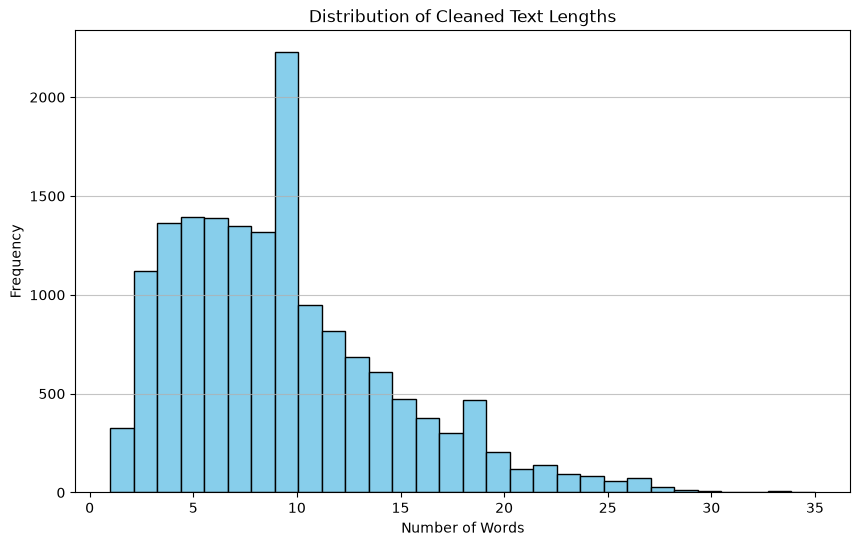

In [16]:
#Q9. (Text Length Analysis)

import matplotlib.pyplot as plt

# Calculate the number of words in each cleaned text
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# Print average, minimum, and maximum text length
print(f"Average Text Length: {df['word_count'].mean():.2f} words")
print(f"Minimum Text Length: {df['word_count'].min()} words")
print(f"Maximum Text Length: {df['word_count'].max()} words")

# Plot a histogram of text lengths
plt.figure(figsize=(10, 6))
plt.hist(df['word_count'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Cleaned Text Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [17]:
#Q10. (Mini Project – Full Preprocessing Pipeline)
# 1. Load the data (already done, reloading fresh copy for completeness if needed)
project_df = pd.read_csv('train.txt', sep=';', header=None, names=['text', 'emotions'])

# 2. Encode the emotion labels
encoder = LabelEncoder()
project_df['encoded_emotions'] = encoder.fit_transform(project_df['emotions'])

# 3. Perform complete text cleaning pipeline
project_df['cleaned_text'] = project_df['text'].apply(clean_text)

# 4. Save the cleaned dataset as cleaned_emotions.csv
project_df.to_csv('cleaned_emotions.csv', index=False)
print("Dataset successfully saved as 'cleaned_emotions.csv'.")

# 5. Show value counts of each emotion
print("\n--- Emotion Value Counts ---")
print(project_df['emotions'].value_counts())

Dataset successfully saved as 'cleaned_emotions.csv'.

--- Emotion Value Counts ---
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
